<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Desafio práctico - Algoritmos Evolutivos I - Ojeda, Juan Cruz

Este trabajo aborda la planificación de personal en una panadería que opera 24 horas. El objetivo es cubrir una demanda horaria variable con el menor costo posible, respetando restricciones operativas habituales: disponibilidad de cada empleado, límites de horas por día y de horas consecutivas, y evitar de patrones poco prácticos como 0-1-0 y 1-0-1. Además, se incorpora un adicional para el trabajo nocturno y una bonificación por continuidad de turnos para favorecer soluciones más realistas.

La solución se implementa con un algoritmo genético utilizando DEAP. La representación se realiza por “slots” de cobertura: cada unidad de demanda en una hora se asigna a un empleado. La función de evaluación combina costo, penalizaciones por violaciones y una bonificación por continuidad. A continuación se presenta el código utilizado para resolver el problema y generar el gráfico de convergencia.

gen	nevals	avg    	min    	max    
0  	500   	24552.6	10143.3	38923.2
1  	405   	19778.9	10042.6	31525.8
2  	410   	16319.6	9178.68	24160.6
3  	414   	13930.8	8263.38	22578.8
4  	423   	12306.9	7112.11	22873.2
5  	415   	11153.4	5980.71	22755.6
6  	413   	10060.4	5407.58	18460.4
7  	424   	9111.43	5407.58	20358.5
8  	418   	8486.18	4541.34	19225.8
9  	434   	7532.74	4008.04	17725.5
10 	429   	6974.05	2605.78	17496.1
11 	434   	5980.44	1925.18	18841.3
12 	403   	5166.78	1925.18	14339.5
13 	426   	4531.16	1774.04	12626.2
14 	420   	3766.12	1232.04	14899.9
15 	418   	3241.83	679.644	12440.2
16 	418   	2665.81	679.644	12529  
17 	412   	2373.23	679.644	10955.2
18 	427   	2169.68	559.911	11449  
19 	412   	1996.71	409.844	11478.1
20 	437   	1743.71	409.844	12156.5
21 	418   	1413.63	409.844	11948.2
22 	413   	1576.04	409.844	12999.3
23 	421   	1365.72	409.844	10815.7
24 	425   	1289.83	409.844	10106.6
25 	426   	1209.87	409.844	14561  
26 	425   	1313.81	409.844	14501.9
27 	428   	1204   	4

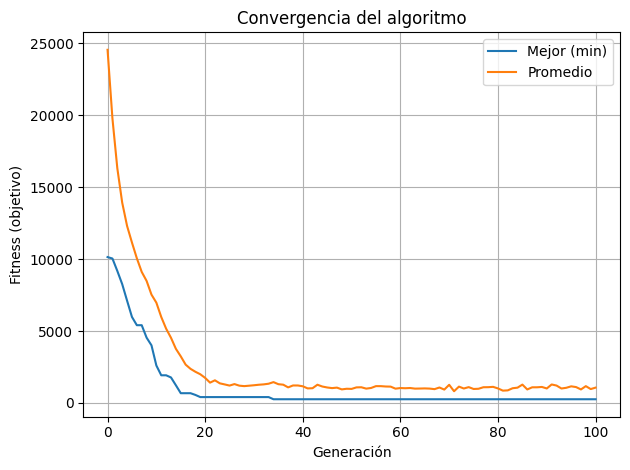

SOLUCIÓN 1 (Objetivo: 259.444)
00:00–01:00 | Demanda=1 | Asignados: Carla
01:00–02:00 | Demanda=1 | Asignados: Carla
02:00–03:00 | Demanda=1 | Asignados: Carla
03:00–04:00 | Demanda=1 | Asignados: Carla
04:00–05:00 | Demanda=1 | Asignados: Carla
05:00–06:00 | Demanda=1 | Asignados: Ana
06:00–07:00 | Demanda=3 | Asignados: Eva, Ana, Diego
07:00–08:00 | Demanda=3 | Asignados: Diego, Ana, Eva
08:00–09:00 | Demanda=3 | Asignados: Diego, Eva, Ana
09:00–10:00 | Demanda=3 | Asignados: Ana, Eva, Diego
10:00–11:00 | Demanda=3 | Asignados: Ana, Diego, Fede
11:00–12:00 | Demanda=1 | Asignados: Fede
12:00–13:00 | Demanda=1 | Asignados: Diego
13:00–14:00 | Demanda=1 | Asignados: Diego
14:00–15:00 | Demanda=1 | Asignados: Diego
15:00–16:00 | Demanda=1 | Asignados: Fede
16:00–17:00 | Demanda=1 | Asignados: Fede
17:00–18:00 | Demanda=3 | Asignados: Bruno, Eva, Diego
18:00–19:00 | Demanda=3 | Asignados: Bruno, Eva, Diego
19:00–20:00 | Demanda=3 | Asignados: Eva, Fede, Bruno
20:00–21:00 | Demanda=3 | As

In [20]:
import random
from collections import defaultdict
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

# ==============================
# DATOS DEL PROBLEMA
# ==============================
# Demanda por hora (0..23): número de personas requeridas por hora
DEMANDA = [1] * 24
for h in range(6, 11):   DEMANDA[h] = 3
for h in range(17, 21):  DEMANDA[h] = 3
for h in range(22, 24):  DEMANDA[h] = 2
for h in range(0, 5):    DEMANDA[h] = 1

# Mapeo lineal de cromosoma: slot -> hora
slot_a_hora = []
for h, d in enumerate(DEMANDA):
    slot_a_hora.extend([h] * d)

# Empleados: costo/hora y disponibilidad (horas permitidas)
empleados = [
    {"nombre": "Ana",   "costo": 1.0, "disp": list(range(5, 14))},
    {"nombre": "Bruno", "costo": 1.2, "disp": list(range(14, 23))},
    {"nombre": "Carla", "costo": 1.1, "disp": list(range(0, 8)) + list(range(20, 24))},
    {"nombre": "Diego", "costo": 0.9, "disp": list(range(6, 19))},
    {"nombre": "Eva",   "costo": 1.4, "disp": list(range(0, 24))},
    {"nombre": "Fede",  "costo": 1.0, "disp": list(range(10, 24))},
]
E = len(empleados)

# Restricciones por empleado
MAX_HORAS   = [8, 8, 8, 10, 8, 8]  # máximo de horas diarias
MAX_CONSEC  = [6, 6, 6, 8, 6, 6]   # máximo de horas consecutivas

# Adicional por nocturnidad
def adicional_nocturno(h):
    return 0.3 if (h < 6 or h >= 22) else 0.0

# ==============================
# PESOS (penalizaciones y bonificaciones)
# ==============================
P_NO_DISP       = 500.0   # asignación fuera de disponibilidad
P_DUP_EN_HORA   = 400.0   # duplicar al mismo empleado dentro de la misma hora
P_EXCEDE_MAX    = 200.0   # excedente de horas diarias
P_CONSEC_EXCESS = 80.0    # excedente de consecutivas
P_COBERTURA     = 2000.0  # slot no cubierto
P_FAIR          = 0.1     # equidad: varianza de horas
P_PATRON_101    = 120.0   # patrón 1-0-1
P_ISOLATED_1H   = 150.0   # bloque aislado de 1 hora
BONUS_CONTIG    = 1.0     # continuidad 1-1

# ==============================
# DEAP
# ==============================
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# Función objetivo (minimización): costo + penalizaciones − bonificaciones
# - Costo: suma de costos por hora asignada (incluye nocturnidad)
# - Penalizaciones: restricciones de disponibilidad, duplicidad, máximos, patrones
# - Bonificaciones: continuidad de horas trabajadas
def evaluar(individuo):
    costo = 0.0
    penal = 0.0
    bonus = 0.0

    # Acumuladores
    horas_por_empleado = [0] * E
    asignados_en_hora = [defaultdict(int) for _ in range(24)]  # h -> {e: count}

    # Asignación por slot
    for s, e in enumerate(individuo):
        if not (0 <= e < E):
            return (10_000.0,)
        h = slot_a_hora[s]
        asignados_en_hora[h][e] += 1
        if h not in empleados[e]["disp"]:
            penal += P_NO_DISP
        costo += empleados[e]["costo"] + adicional_nocturno(h)

    # Duplicidad dentro de la misma hora y horas efectivas por empleado
    for h in range(24):
        for e, cnt in asignados_en_hora[h].items():
            if cnt > 1:
                penal += P_DUP_EN_HORA * (cnt - 1)
            if cnt >= 1:
                horas_por_empleado[e] += 1

    # Límite diario de horas
    for e in range(E):
        excede = max(0, horas_por_empleado[e] - MAX_HORAS[e])
        if excede > 0:
            penal += P_EXCEDE_MAX * excede

    # Consecutivas, patrones y continuidad
    for e in range(E):
        consec = 0
        maxc = MAX_CONSEC[e]
        day = [1 if asignados_en_hora[h].get(e, 0) >= 1 else 0 for h in range(24)]
        # Exceso de consecutivas + bonus por continuidad (1-1)
        for h in range(24):
            if day[h] == 1:
                consec += 1
                if consec > maxc:
                    penal += P_CONSEC_EXCESS * (consec - maxc)
                if h > 0 and day[h-1] == 1:
                    bonus += BONUS_CONTIG
            else:
                consec = 0
        # Bloques aislados (0-1-0) y patrón 1-0-1
        for h in range(24):
            if day[h] == 1:
                left0  = (h == 0)  or (day[h-1] == 0)
                right0 = (h == 23) or (day[h+1] == 0)
                if left0 and right0:
                    penal += P_ISOLATED_1H
            if 0 < h < 23 and day[h-1] == 1 and day[h] == 0 and day[h+1] == 1:
                penal += P_PATRON_101

    # Cobertura por hora
    for h, d in enumerate(DEMANDA):
        cubiertos = sum(1 for _e, cnt in asignados_en_hora[h].items() if cnt >= 1)
        if cubiertos < d:
            penal += P_COBERTURA * (d - cubiertos)

    # Equidad
    media = sum(horas_por_empleado) / E
    var = sum((x - media) ** 2 for x in horas_por_empleado) / E
    costo -= P_FAIR * var

    objetivo = costo + penal - bonus
    return (objetivo,)

# Individuos: asignación de un empleado a cada slot
def crear_individuo():
    return creator.Individual([random.randrange(E) for _ in range(len(slot_a_hora))])

# Mutación uniforme sobre empleados asignados a slots
def mutar_individuo(individuo, indpb=0.1):
    for i in range(len(individuo)):
        if random.random() < indpb:
            individuo[i] = random.randrange(E)
    return individuo,

# Cruce de dos puntos
def crossover_individuos(ind1, ind2):
    tools.cxTwoPoint(ind1, ind2)
    return ind1, ind2

# ==============================
# TOOLBOX y EJECUCIÓN
# ==============================
toolbox = base.Toolbox()
toolbox.register("individual", crear_individuo)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluar)
toolbox.register("mate", crossover_individuos)
toolbox.register("mutate", mutar_individuo, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=5)

def main():
    # random.seed(42)

    pop = toolbox.population(n=500)
    hof = tools.HallOfFame(3)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", lambda xs: sum(v[0] for v in xs)/len(xs))
    stats.register("min", lambda xs: min(v[0] for v in xs))
    stats.register("max", lambda xs: max(v[0] for v in xs))

    pop, logbook = algorithms.eaSimple(
        pop, toolbox,
        cxpb=0.8, mutpb=0.2, ngen=100,
        stats=stats, halloffame=hof, verbose=True
    )

    gens = logbook.select("gen")
    fit_min = logbook.select("min")
    fit_avg = logbook.select("avg")

    plt.figure()
    plt.plot(gens, fit_min, label="Mejor (min)")
    plt.plot(gens, fit_avg, label="Promedio")
    plt.xlabel("Generación")
    plt.ylabel("Fitness (objetivo)")
    plt.title("Convergencia del algoritmo")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("convergencia.png", dpi=150)
    plt.show()

    for k, mejor in enumerate(hof, 1):
        print("" + "="*60)
        print(f"SOLUCIÓN {k} (Objetivo: {mejor.fitness.values[0]:.3f})")
        print("="*60)

        por_hora = defaultdict(list)
        for s, e in enumerate(mejor):
            h = slot_a_hora[s]
            por_hora[h].append(empleados[e]["nombre"])

        for h in range(24):
            requeridos = DEMANDA[h]
            asignados = por_hora.get(h, [])
            print(f"{h:02d}:00–{(h+1)%24:02d}:00 | Demanda={requeridos} | Asignados: {', '.join(asignados) if asignados else '(vacío)'}")

        print("Horas por empleado:")
        cont = defaultdict(int)
        for h in range(24):
            for nombre in set(por_hora.get(h, [])):
                cont[nombre] += 1
        for emp in empleados:
            print(f"  {emp['nombre']}: {cont[emp['nombre']]} h")

if __name__ == "__main__":
    main()
